In [1]:
import os
os.environ["SYNOPTIC_TOKEN"] = "b1ab132d60f04cb4b6eb3e7d9f31699b"

# Phase 1 — Synoptic Network Audit + ITD RWIS Overlap

This notebook assumes `out/stations_all.csv` exists (from `01_phase1_ingest_match.ipynb`).

Outputs:
- `out/networks_in_idaho.csv`
- `out/metadata_completeness_by_network.csv`
- `out/overlap_synoptic_vs_ITD_Rwis.csv`


In [2]:
import os
import time
import math
from datetime import datetime, timezone
from typing import Dict, Any, List, Optional

import requests
import pandas as pd

# ---- Config ----
SYNOPTIC_TOKEN = os.getenv("SYNOPTIC_TOKEN", "").strip()

STATIONS_ALL_CSV = "out/stations_all.csv"
OUT_NETWORKS_IN_IDAHO = "out/networks_in_idaho.csv"
OUT_META_COMPLETENESS = "out/metadata_completeness_by_network.csv"
OUT_OVERLAP_ITD_RWIS = "out/overlap_synoptic_vs_ITD_Rwis.csv"

MAX_DIST_M = 200.0

# Synoptic endpoints
SYNOPTIC_NETWORKS_URL = "https://api.synopticdata.com/v2/networks"
SYNOPTIC_METADATA_URL = "https://api.synopticdata.com/v2/stations/metadata"

# ITD RWIS (ArcGIS REST layer)
ITD_RWIS_LAYER = "https://gis.itd.idaho.gov/arcgisprod/rest/services/ArcGISOnline/RoadFeatureLayers/MapServer/6"
ITD_RWIS_QUERY = ITD_RWIS_LAYER + "/query"


In [3]:
def utcnow_iso() -> str:
    return datetime.now(timezone.utc).isoformat(timespec="seconds")

def haversine_m(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    R = 6371000.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dl/2)**2
    return 2*R*math.atan2(math.sqrt(a), math.sqrt(1-a))

def safe_get_json(url: str, params: Dict[str, Any], timeout: int = 60) -> Dict[str, Any]:
    r = requests.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    return r.json()


In [4]:
def fetch_synoptic_networks(token: str, timeout: int = 60) -> pd.DataFrame:
    """Fetch Synoptic network table, normalize to include 'mnet_id'."""
    if not token:
        raise ValueError("SYNOPTIC_TOKEN not set.")
    js = safe_get_json(SYNOPTIC_NETWORKS_URL, {"token": token}, timeout=timeout)

    nets = js.get("MNET") or js.get("NETWORKS") or js.get("networks") or []
    net = pd.DataFrame(nets)

    # Normalize the network id column to 'mnet_id'
    if "ID" in net.columns:
        net["mnet_id"] = net["ID"].astype(str).str.strip()
    elif "id" in net.columns:
        net["mnet_id"] = net["id"].astype(str).str.strip()
    elif "MNET_ID" in net.columns:
        net["mnet_id"] = net["MNET_ID"].astype(str).str.strip()
    else:
        raise RuntimeError(f"Cannot find network id column in networks payload. Columns={net.columns.tolist()}")

    # Helpful standard columns (may or may not exist depending on payload)
    for c in ["SHORTNAME","LONGNAME","URL","PROGRAM","CATEGORY"]:
        if c not in net.columns and c.lower() in net.columns:
            net[c] = net[c.lower()]

    return net


In [5]:
def build_networks_in_idaho(stations_all: pd.DataFrame, networks_df: pd.DataFrame) -> pd.DataFrame:
    syn = stations_all[stations_all["source"] == "SYNOPTIC"].copy()
    syn = syn.dropna(subset=["network_id", "source_station_id"]).copy()
    syn["network_id"] = syn["network_id"].astype(str).str.strip()

    counts = syn.groupby("network_id")["station_uid"].nunique().reset_index()
    counts.rename(columns={"network_id":"mnet_id", "station_uid":"n_stations"}, inplace=True)

    out = counts.merge(networks_df, on="mnet_id", how="left")
    out["generated_utc"] = utcnow_iso()
    out = out.sort_values("n_stations", ascending=False).reset_index(drop=True)
    return out


In [6]:
import pandas as pd

def metadata_completeness_by_network(stations_all: pd.DataFrame) -> pd.DataFrame:
    """Baseline completeness for Synoptic stations by network_id using columns available in stations_all."""
    syn = stations_all[stations_all["source"] == "SYNOPTIC"].copy()
    syn = syn.dropna(subset=["network_id", "source_station_id"]).copy()
    syn["network_id"] = syn["network_id"].astype(str).str.strip()

    # Ensure columns exist (if not, create as all-NA)
    expected_cols = [
        "latitude", "longitude", "elevation_m",
        "timezone", "county",
        "providers_json", "siting_json", "period_of_record_json"
    ]
    for c in expected_cols:
        if c not in syn.columns:
            syn[c] = pd.NA

    def pct_true(mask: pd.Series) -> float:
        return round(100.0 * float(mask.mean()), 2) if len(mask) else 0.0

    def pct_nonnull(s: pd.Series) -> float:
        return round(100.0 * float(s.notna().mean()), 2) if len(s) else 0.0

    rows = []
    for mnet_id, g in syn.groupby("network_id"):
        rec = {
            "mnet_id": str(mnet_id),
            "n_stations": int(g["station_uid"].nunique()) if "station_uid" in g.columns else int(len(g))
        }
        rec["has_latlon_pct"] = pct_true(g["latitude"].notna() & g["longitude"].notna())
        rec["has_elevation_pct"] = pct_nonnull(g["elevation_m"])
        rec["has_timezone_pct"] = pct_nonnull(g["timezone"])
        rec["has_county_pct"] = pct_nonnull(g["county"])
        rec["has_providers_pct"] = pct_nonnull(g["providers_json"])
        rec["has_siting_pct"] = pct_nonnull(g["siting_json"])
        rec["has_period_of_record_pct"] = pct_nonnull(g["period_of_record_json"])
        rows.append(rec)

    out = pd.DataFrame(rows)
    out["generated_utc"] = utcnow_iso()  # usa la tua funzione già presente
    if not out.empty:
        out = out.sort_values("n_stations", ascending=False).reset_index(drop=True)
    return out

In [7]:
def fetch_itd_rwis_points(timeout: int = 60) -> pd.DataFrame:
    """Download RWIS point features from ITD ArcGIS REST as GeoJSON."""
    params = {
        "where": "1=1",
        "outFields": "*",
        "returnGeometry": "true",
        "f": "geojson",
        "resultRecordCount": 10000,
    }
    js = safe_get_json(ITD_RWIS_QUERY, params=params, timeout=timeout)
    feats = js.get("features", []) or []

    rows = []
    for f in feats:
        geom = f.get("geometry") or {}
        props = f.get("properties") or {}

        lon = geom.get("coordinates", [None, None])[0]
        lat = geom.get("coordinates", [None, None])[1]

        rows.append({
            "itd_site_id": props.get("SiteID") or props.get("SITEID") or props.get("siteid") or props.get("OBJECTID"),
            "itd_name": props.get("SiteName") or props.get("SITENAME") or props.get("sitename") or props.get("Name"),
            "latitude": pd.to_numeric(lat, errors="coerce"),
            "longitude": pd.to_numeric(lon, errors="coerce"),
        })

    out = pd.DataFrame(rows).dropna(subset=["latitude","longitude"]).reset_index(drop=True)
    return out


In [8]:
def overlap_synoptic_vs_itd(stations_all: pd.DataFrame, itd_df: pd.DataFrame, max_dist_m: float = MAX_DIST_M) -> pd.DataFrame:
    syn = stations_all[stations_all["source"] == "SYNOPTIC"].copy()
    syn = syn.dropna(subset=["latitude", "longitude", "source_station_id"]).reset_index(drop=True)

    matches = []
    for _, s in syn.iterrows():
        lat1, lon1 = float(s["latitude"]), float(s["longitude"])
        best = None
        best_d = None

        for _, r in itd_df.iterrows():
            d = haversine_m(lat1, lon1, float(r["latitude"]), float(r["longitude"]))
            if d <= max_dist_m and (best_d is None or d < best_d):
                best_d = d
                best = r

        if best is not None:
            matches.append({
                "SYNOPTIC_uid": s.get("station_uid"),
                "SYNOPTIC_stid": s.get("source_station_id"),
                "SYNOPTIC_name": s.get("station_name"),
                "SYNOPTIC_mnet_id": s.get("network_id"),
                "ITD_site_id": best.get("itd_site_id"),
                "ITD_name": best.get("itd_name"),
                "dist_m": float(best_d),
                "generated_utc": utcnow_iso(),
            })

    return pd.DataFrame(matches).sort_values("dist_m").reset_index(drop=True) if matches else pd.DataFrame()


In [9]:
# ---- Run audit ----
stations_all = pd.read_csv(STATIONS_ALL_CSV)

networks_df = fetch_synoptic_networks(SYNOPTIC_TOKEN)

print("Unique network_id in stations (Synoptic):",
      stations_all[stations_all.source=="SYNOPTIC"]["network_id"].nunique())
print("Unique mnet_id in networks table:",
      networks_df["mnet_id"].nunique())

networks_in_id = build_networks_in_idaho(stations_all, networks_df)
networks_in_id.to_csv(OUT_NETWORKS_IN_IDAHO, index=False)
print(f"[OUT] {OUT_NETWORKS_IN_IDAHO} ({len(networks_in_id)} networks)")

meta_comp = metadata_completeness_by_network(stations_all)
meta_comp.to_csv(OUT_META_COMPLETENESS, index=False)
print(f"[OUT] {OUT_META_COMPLETENESS} ({len(meta_comp)} networks)")
display(meta_comp.head(12))
# ITD overlap
itd = fetch_itd_rwis_points()
ov = overlap_synoptic_vs_itd(stations_all, itd, MAX_DIST_M)
ov.to_csv(OUT_OVERLAP_ITD_RWIS, index=False)
print(f"[OUT] {OUT_OVERLAP_ITD_RWIS} ({len(ov)} matches within {MAX_DIST_M} m)")

# quick look
networks_in_id.head(10), meta_comp.head(10), ov.head(10)


Unique network_id in stations (Synoptic): 41
Unique mnet_id in networks table: 398
[OUT] out/networks_in_idaho.csv (41 networks)
[OUT] out/metadata_completeness_by_network.csv (41 networks)


,mnet_id,n_stations,has_latlon_pct,has_elevation_pct,has_timezone_pct,has_county_pct,has_providers_pct,has_siting_pct,has_period_of_record_pct,generated_utc
0,2.0,156,100.0,100.0,0.0,0.0,0.0,0.0,0.0,2026-02-17T16:31:44+00:00
1,41.0,129,100.0,100.0,0.0,0.0,0.0,0.0,0.0,2026-02-17T16:31:44+00:00
2,204.0,116,100.0,100.0,0.0,0.0,0.0,0.0,0.0,2026-02-17T16:31:44+00:00
3,3022.0,95,100.0,100.0,0.0,0.0,0.0,0.0,0.0,2026-02-17T16:31:44+00:00
4,65.0,94,100.0,100.0,0.0,0.0,0.0,0.0,0.0,2026-02-17T16:31:44+00:00
5,25.0,83,100.0,100.0,0.0,0.0,0.0,0.0,0.0,2026-02-17T16:31:44+00:00
6,317.0,79,100.0,100.0,0.0,0.0,0.0,0.0,0.0,2026-02-17T16:31:44+00:00
7,106.0,52,100.0,100.0,0.0,0.0,0.0,0.0,0.0,2026-02-17T16:31:44+00:00
8,247.0,42,100.0,100.0,0.0,0.0,0.0,0.0,0.0,2026-02-17T16:31:44+00:00
9,5.0,35,100.0,100.0,0.0,0.0,0.0,0.0,0.0,2026-02-17T16:31:44+00:00


[OUT] out/overlap_synoptic_vs_ITD_Rwis.csv (119 matches within 200.0 m)


(  mnet_id  n_stations   ID SHORTNAME LONGNAME  URL CITATION PROGRAM CATEGORY  \
 0     2.0         156  NaN       NaN      NaN  NaN      NaN     NaN      NaN   
 1    41.0         129  NaN       NaN      NaN  NaN      NaN     NaN      NaN   
 2   204.0         116  NaN       NaN      NaN  NaN      NaN     NaN      NaN   
 3  3022.0          95  NaN       NaN      NaN  NaN      NaN     NaN      NaN   
 4    65.0          94  NaN       NaN      NaN  NaN      NaN     NaN      NaN   
 5    25.0          83  NaN       NaN      NaN  NaN      NaN     NaN      NaN   
 6   317.0          79  NaN       NaN      NaN  NaN      NaN     NaN      NaN   
 7   106.0          52  NaN       NaN      NaN  NaN      NaN     NaN      NaN   
 8   247.0          42  NaN       NaN      NaN  NaN      NaN     NaN      NaN   
 9     5.0          35  NaN       NaN      NaN  NaN      NaN     NaN      NaN   
 
   LAST_OBSERVATION  REPORTING_STATIONS  ACTIVE_STATIONS  TOTAL_STATIONS  \
 0              NaN            

In [10]:
# --- Load overlap results ---
ov_itd = pd.read_csv(OUT_OVERLAP_ITD_RWIS)

# Matched ITD site_ids
matched_itd_ids = set(ov_itd["ITD_site_id"])

# Fetch official ITD stations again
itd_official = fetch_itd_rwis_points()

all_itd_ids = set(itd_official["site_id"])

missing_itd_ids = all_itd_ids - matched_itd_ids

missing_itd = itd_official[itd_official["site_id"].isin(missing_itd_ids)].copy()

missing_itd.to_csv(os.path.join(OUT_DIR, "missing_itd_not_in_synoptic.csv"), index=False)

print("Total ITD official:", len(all_itd_ids))
print("Matched in Synoptic:", len(matched_itd_ids))
print("Missing in Synoptic:", len(missing_itd))

KeyError: 'site_id'

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "out"
FIG_DIR = os.path.join(OUT_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

net = pd.read_csv(os.path.join(OUT_DIR, "networks_in_idaho.csv"))
meta = pd.read_csv(os.path.join(OUT_DIR, "metadata_completeness_by_network.csv"))
ov_itd = pd.read_csv(os.path.join(OUT_DIR, "overlap_synoptic_vs_ITD_Rwis.csv"))

print(net.shape, meta.shape, ov_itd.shape)

(41, 20) (41, 10) (119, 8)


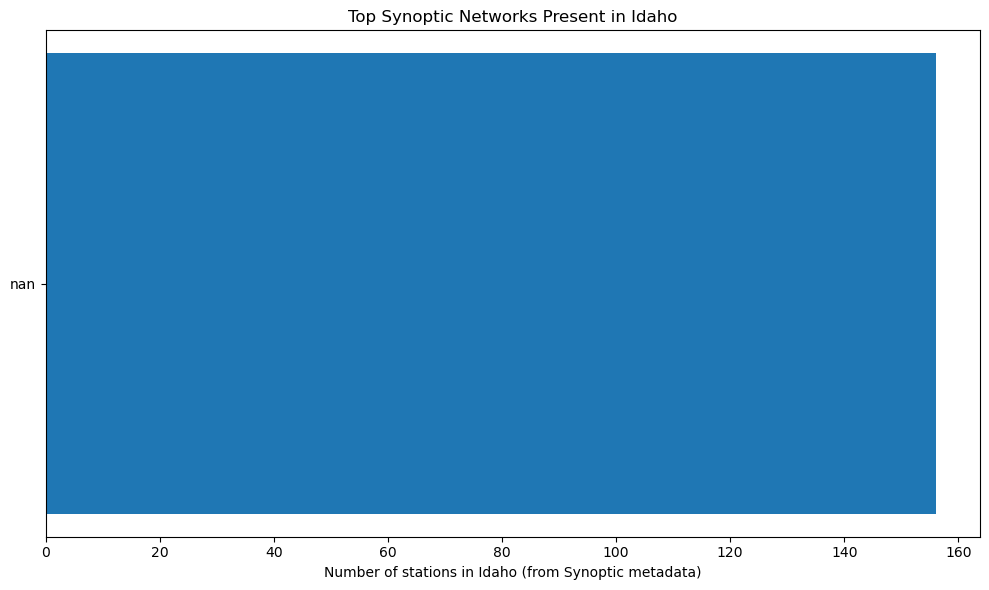

'out/figs/fig01_top_networks_idaho.png'

In [21]:
topn = 15
d = net.sort_values("n_stations", ascending=False).head(topn).copy()

# label leggibile
def label_row(r):
    sn = str(r.get("SHORTNAME") or "").strip()
    ln = str(r.get("LONGNAME") or "").strip()
    return sn if sn else (ln[:40] + "…" if len(ln) > 40 else ln) or f"mnet {r['mnet_id']}"

d["label"] = d.apply(label_row, axis=1)

plt.figure(figsize=(10, 6))
plt.barh(d["label"][::-1], d["n_stations"][::-1])
plt.xlabel("Number of stations in Idaho (from Synoptic metadata)")
plt.title("Top Synoptic Networks Present in Idaho")
plt.tight_layout()
png = os.path.join(FIG_DIR, "fig01_top_networks_idaho.png")
plt.savefig(png, dpi=200)
plt.show()

png

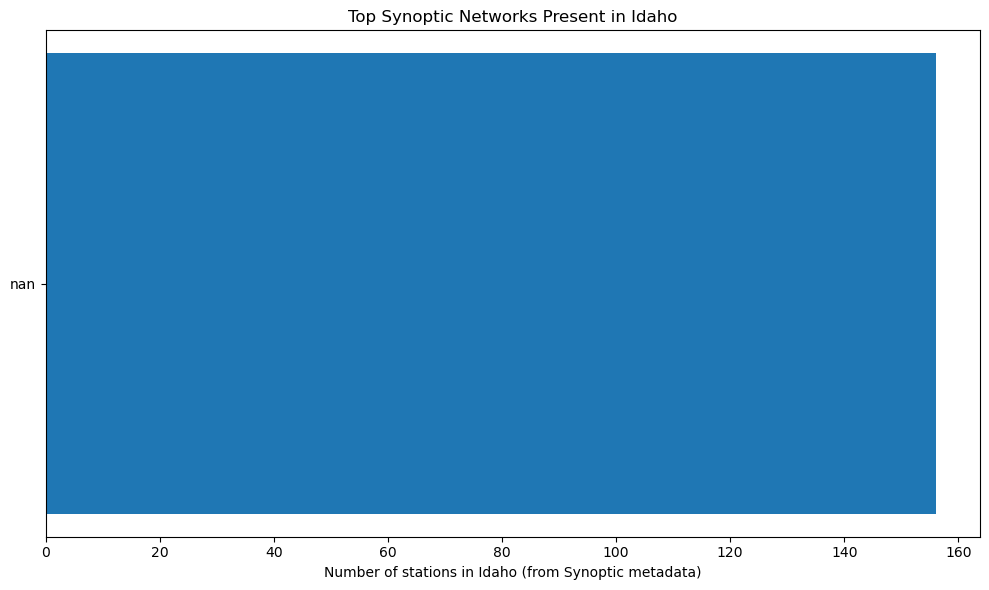

'out/figs/fig01_top_networks_idaho.png'

In [22]:
topn = 15
d = net.sort_values("n_stations", ascending=False).head(topn).copy()

# label leggibile
def label_row(r):
    sn = str(r.get("SHORTNAME") or "").strip()
    ln = str(r.get("LONGNAME") or "").strip()
    return sn if sn else (ln[:40] + "…" if len(ln) > 40 else ln) or f"mnet {r['mnet_id']}"

d["label"] = d.apply(label_row, axis=1)

plt.figure(figsize=(10, 6))
plt.barh(d["label"][::-1], d["n_stations"][::-1])
plt.xlabel("Number of stations in Idaho (from Synoptic metadata)")
plt.title("Top Synoptic Networks Present in Idaho")
plt.tight_layout()
png = os.path.join(FIG_DIR, "fig01_top_networks_idaho.png")
plt.savefig(png, dpi=200)
plt.show()

png

In [23]:
cols_show = ["mnet_id","n_stations","SHORTNAME","LONGNAME","URL","PROGRAM","CATEGORY"]
net.sort_values("n_stations", ascending=False)[cols_show].head(20)

,mnet_id,n_stations,SHORTNAME,LONGNAME,URL,PROGRAM,CATEGORY
0,2.0,156,NaN,NaN,NaN,NaN,NaN
1,41.0,129,NaN,NaN,NaN,NaN,NaN
2,204.0,116,NaN,NaN,NaN,NaN,NaN
3,3022.0,95,NaN,NaN,NaN,NaN,NaN
4,65.0,94,NaN,NaN,NaN,NaN,NaN
5,25.0,83,NaN,NaN,NaN,NaN,NaN
6,317.0,79,NaN,NaN,NaN,NaN,NaN
7,106.0,52,NaN,NaN,NaN,NaN,NaN
8,247.0,42,NaN,NaN,NaN,NaN,NaN
9,5.0,35,NaN,NaN,NaN,NaN,NaN


In [24]:
(net.sort_values("n_stations", ascending=False)[cols_show]
 .head(20)
 .style
 .set_properties(**{"font-size":"11pt"})
)

,mnet_id,n_stations,SHORTNAME,LONGNAME,URL,PROGRAM,CATEGORY
0,2.000000,156,nan,nan,nan,nan,nan
1,41.000000,129,nan,nan,nan,nan,nan
2,204.000000,116,nan,nan,nan,nan,nan
3,3022.000000,95,nan,nan,nan,nan,nan
4,65.000000,94,nan,nan,nan,nan,nan
5,25.000000,83,nan,nan,nan,nan,nan
6,317.000000,79,nan,nan,nan,nan,nan
7,106.000000,52,nan,nan,nan,nan,nan
8,247.000000,42,nan,nan,nan,nan,nan
9,5.000000,35,nan,nan,nan,nan,nan


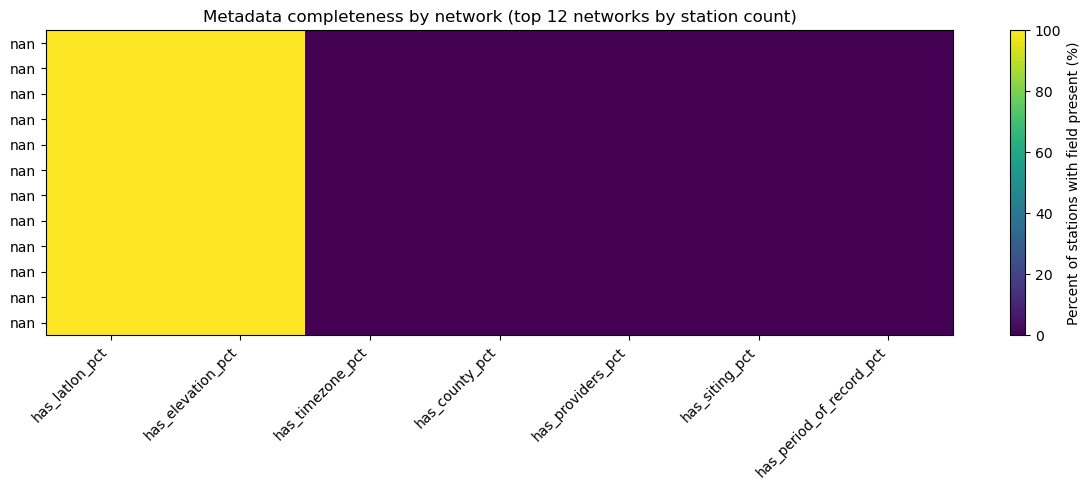

'out/figs/fig02_metadata_completeness_heatmap.png'

In [25]:
# scegli i campi percentuali (colonne *_pct)
pct_cols = [c for c in meta.columns if c.endswith("_pct")]
m = meta.sort_values("n_stations", ascending=False).head(12).copy()

# etichette rete
m = m.merge(net[["mnet_id","SHORTNAME","LONGNAME"]], on="mnet_id", how="left")

def net_label(r):
    sn = str(r.get("SHORTNAME") or "").strip()
    if sn: return sn
    ln = str(r.get("LONGNAME") or "").strip()
    return ln[:25] + "…" if len(ln) > 25 else ln or str(r["mnet_id"])

m["label"] = m.apply(net_label, axis=1)

# matrice per imshow
Z = m[pct_cols].to_numpy()

plt.figure(figsize=(12, 5))
plt.imshow(Z, aspect="auto")
plt.yticks(range(len(m)), m["label"])
plt.xticks(range(len(pct_cols)), pct_cols, rotation=45, ha="right")
plt.title("Metadata completeness by network (top 12 networks by station count)")
plt.colorbar(label="Percent of stations with field present (%)")
plt.tight_layout()
png = os.path.join(FIG_DIR, "fig02_metadata_completeness_heatmap.png")
plt.savefig(png, dpi=200)
plt.show()

png

ITD matches within threshold: 119


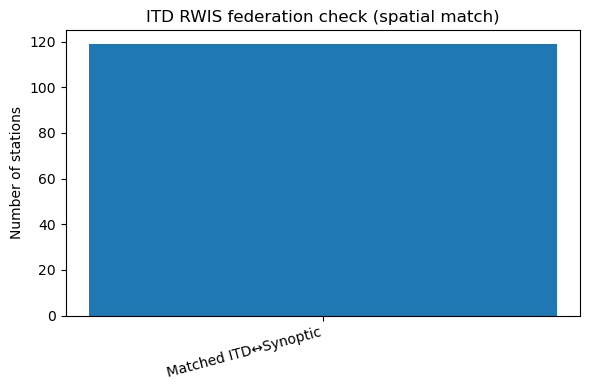

'out/figs/fig03_itd_federation_bar.png'

In [26]:
# Quante stazioni ITD federate (in Synoptic) hai matchato?
n_matches = len(ov_itd)
print("ITD matches within threshold:", n_matches)

# Se nel notebook 2 hai anche itd_official (tutte le stazioni dal layer ITD),
# calcoliamo anche quante mancano.
# Se non ce l'hai in una variabile, carica dal file che usi nel fetch:
# itd_official = pd.read_csv("...")  # deve contenere ITD_site_id
try:
    itd_official = df_itd_official.copy()  # se esiste nel notebook
except Exception:
    itd_official = None

if itd_official is not None and "ITD_site_id" in itd_official.columns:
    n_itd_total = itd_official["ITD_site_id"].nunique()
    n_missing = n_itd_total - ov_itd["ITD_site_id"].nunique()
    labels = ["Matched (federated in Synoptic)", "Missing (not matched)"]
    values = [n_itd_total - n_missing, n_missing]
else:
    labels = ["Matched ITD↔Synoptic"]
    values = [n_matches]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("Number of stations")
plt.title("ITD RWIS federation check (spatial match)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
png = os.path.join(FIG_DIR, "fig03_itd_federation_bar.png")
plt.savefig(png, dpi=200)
plt.show()

png

In [27]:
sorted([f for f in os.listdir(FIG_DIR) if f.endswith(".png")])

['fig01_top_networks_idaho.png',
 'fig02_metadata_completeness_heatmap.png',
 'fig03_itd_federation_bar.png']